# 01 - Simulate PD-Centric Quarterly Panel

This notebook creates a clean synthetic quarterly panel for later PTO, black-box, and DFL notebooks.

The simulation is PD-centric and frequency-consistent:

- the latent credit-risk process is a true quarterly PD process, `PD_quarterly_true`;
- annual PD is derived as `PD_annual_true = 1 - (1 - PD_quarterly_true) ** 4` for Basel IRB;
- realised quarterly default and charge-off rates are sampled conditional on `PD_quarterly_true`;
- the Vasicek asset correlation and Basel IRB capital use `PD_annual_true`;
- oracle allocations use realised quarterly charge-offs and a linear shortfall penalty.

## Frequency Convention

The empirical FRED `charge_off_rate` series is observed quarterly but reported at an annualised rate. The allocation problem is quarterly, so the simulated realised loss `c` is a quarterly charge-off rate.

The main calibration target is therefore quarterly. The historical annualised charge-off series is converted to a quarterly charge-off proxy and then to a quarterly PD proxy:

```python
hist_c_quarterly = hist_c_annualised / 4
hist_pd_quarterly = hist_c_quarterly / LGD
hist_pd_annual = 1 - (1 - hist_pd_quarterly) ** 4
```

The simulated process starts with `PD_quarterly_true`. Annual PD is derived from it for Basel IRB:

```python
PD_annual_true = 1 - (1 - PD_quarterly_true) ** 4
```

Later models may use only `feature_cols` as inputs. They must not use true PD, expected charge-offs, IRB capital, oracle allocations, or latent diagnostic columns as features.

## Part 1 - Imports, paths, and empirical target data

In [207]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

pd.set_option("display.float_format", "{:.6f}".format)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks" and PROJECT_ROOT.parent.name == "simulation":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "simulation"

CSV_PATH = DATA_DIR / "simulated_pd_panel.csv"
METADATA_PATH = DATA_DIR / "simulated_pd_panel_metadata.json"
HIST_CHARGE_OFF_PATH = PROCESSED_DATA_DIR / "fred_loan_return_aligned.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Historical charge-off file: {HIST_CHARGE_OFF_PATH}")
print(f"CSV output: {CSV_PATH}")
print(f"Figure directory: {FIGURE_DIR}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Historical charge-off file: /Users/hannahokeeffe/Documents/Imperial/DFL_New/data/processed/fred_loan_return_aligned.csv
CSV output: /Users/hannahokeeffe/Documents/Imperial/DFL_New/data/simulated_pd_panel.csv
Figure directory: /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation


## Simulation calibration

Change this cell to recalibrate the panel. The key quarterly PD calibration controls are `beta0`, `beta1`, `pd_min`, and `pd_max`; the key allocation controls are `ell` and `lambda_shortfall`.

`AUTO_CALIBRATE_PD = True` searches over `beta0` and `beta1` to match the historical quarterly PD proxy mean and p95. Set it to `False` to use the hand-set beta values.

In [238]:
# Baseline sample and random seed
T = 1000
SEED = 42

# Credit and allocation constants
LGD = 0.45
K1 = 1.0
ell = 15
Y_BAR = 0.0168
lambda_shortfall = 10.0
M = 2.5
alpha_grid = np.linspace(0, 1, 101)

# Numerical clipping for inverse-normal and log calculations
PD_CLIP_LOW = 1e-6
PD_CLIP_HIGH = 0.99

# Quarterly PD calibration bounds. These are one-quarter PDs, not annual PDs.
pd_min = 0.001
pd_max = 0.025
beta0 = -2.10
beta1 = 1.10
beta2 = 0.25
AUTO_CALIBRATE_PD = True

print("Calibration loaded.")

Calibration loaded.


## Part 2 - Historical quarterly calibration targets

In [239]:
hist = pd.read_csv(HIST_CHARGE_OFF_PATH)
hist_c_annualised_raw = hist["charge_off_rate"].dropna().astype(float)

# In this project the FRED annualised rate is stored in percent units when values
# exceed 1. Convert to decimal rates before applying frequency transformations.
charge_off_scale = 100.0 if hist_c_annualised_raw.max() > 1 else 1.0
hist_c_annualised = hist_c_annualised_raw / charge_off_scale

# Convert the annualised empirical charge-off rate to the quarterly decision frequency.
hist_c_quarterly = hist_c_annualised / 4
hist_pd_quarterly = (hist_c_quarterly / LGD).clip(PD_CLIP_LOW, PD_CLIP_HIGH)
hist_pd_annual = 1 - (1 - hist_pd_quarterly) ** 4

print(f"Historical charge-off scale divisor: {charge_off_scale:g}")
print("Historical quarterly charge-off target, decimal units:")
display(hist_c_quarterly.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("hist_c_quarterly"))
print("Historical quarterly PD proxy, decimal units:")
display(hist_pd_quarterly.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("hist_pd_quarterly"))
print("Historical annual PD proxy for IRB comparison, decimal units:")
display(hist_pd_annual.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("hist_pd_annual"))

Historical charge-off scale divisor: 100
Historical quarterly charge-off target, decimal units:


,hist_c_quarterly
count,165.000000
mean,0.001889
std,0.001433
min,0.000300
50%,0.001375
75%,0.003000
90%,0.003820
95%,0.004710
99%,0.005819
max,0.006425


Historical quarterly PD proxy, decimal units:


,hist_pd_quarterly
count,165.000000
mean,0.004197
std,0.003185
min,0.000667
50%,0.003056
75%,0.006667
90%,0.008489
95%,0.010467
99%,0.012931
max,0.014278


Historical annual PD proxy for IRB comparison, decimal units:


,hist_pd_annual
count,165.000000
mean,0.016623
std,0.012519
min,0.002664
50%,0.012166
75%,0.026401
90%,0.033525
95%,0.041214
99%,0.050729
max,0.055900


## Part 3 - Basel helper functions

In [240]:
def clip_pd(pd, low=PD_CLIP_LOW, high=PD_CLIP_HIGH):
    """Clip PD values to avoid numerical issues in log and inverse-normal terms."""
    return np.clip(np.asarray(pd, dtype=float), low, high)


def sigmoid(x):
    """Logistic transform used to map latent stress into bounded PDs."""
    return 1 / (1 + np.exp(-x))


def basel_R(pd_annual):
    """Corporate Basel asset correlation using annual PD."""
    pd_annual = clip_pd(pd_annual)
    exp_term = (1 - np.exp(-50 * pd_annual)) / (1 - np.exp(-50))
    return 0.12 * exp_term + 0.24 * (1 - exp_term)


def maturity_adjustment(pd_annual, M=2.5):
    """Basel maturity adjustment for corporate exposures, using annual PD."""
    pd_annual = clip_pd(pd_annual)
    b = (0.11852 - 0.05478 * np.log(pd_annual)) ** 2
    return (1 + (M - 2.5) * b) / (1 - 1.5 * b)


def k_irb(pd_annual, lgd=0.45, M=2.5):
    """Basel IRB capital requirement per unit exposure using annual PD."""
    pd_annual = clip_pd(pd_annual)
    R = basel_R(pd_annual)
    numerator = norm.ppf(pd_annual) + np.sqrt(R) * norm.ppf(0.999)
    denominator = np.sqrt(1 - R)
    unexpected_loss = norm.cdf(numerator / denominator) - pd_annual
    return lgd * unexpected_loss * maturity_adjustment(pd_annual, M=M)

## Part 4 - Vasicek quarterly default-rate sampler

In [241]:
def sample_vasicek_default_rate(pd_quarterly_true, pd_annual_true, seed=None):
    """Draw quarterly default and charge-off rates from the Vasicek model.

    The default threshold uses the quarterly PD because losses are realised over
    one quarter. The asset correlation uses annual PD, matching the Basel IRB
    convention used for capital.
    """
    rng = np.random.default_rng(seed)
    pd_quarterly_true = clip_pd(pd_quarterly_true)
    pd_annual_true = clip_pd(pd_annual_true)
    rho = basel_R(pd_annual_true)
    Z = rng.normal(0, 1, size=pd_quarterly_true.shape)

    default_rate_q = norm.cdf(
        (norm.ppf(pd_quarterly_true) - np.sqrt(rho) * Z) / np.sqrt(1 - rho)
    )
    default_rate_q = np.clip(default_rate_q, 0, 1)
    charge_off_rate_q = np.clip(LGD * default_rate_q, 0, LGD)
    return default_rate_q, charge_off_rate_q

## Part 5 - Simulate latent macro state

In [242]:
def simulate_latent_state(T=1000, phi=0.95, sigma=0.35, seed=42):
    """Simulate persistent latent stress and a second persistent component."""
    rng = np.random.default_rng(seed)
    state = np.zeros(T)
    cycle = np.zeros(T)

    for t in range(1, T):
        state[t] = phi * state[t - 1] + rng.normal(0, sigma)
        cycle[t] = 0.75 * cycle[t - 1] + rng.normal(0, 0.45)

    state = (state - state.mean()) / state.std(ddof=0)
    cycle = (cycle - cycle.mean()) / cycle.std(ddof=0)
    return pd.DataFrame({"latent_state": state, "latent_cycle": cycle})


latent = simulate_latent_state(T=T, seed=SEED)
latent.head()

,latent_state,latent_cycle
0,0.423821,0.115482
1,0.520914,-0.610616
2,0.755177,0.227594
3,0.116947,-0.709592
4,0.173025,-0.724119


## Part 6 - Generate observed macro variables

In [243]:
def generate_macro_variables(latent_df, seed=43):
    """Create noisy observed macro-financial predictors from latent stress."""
    rng = np.random.default_rng(seed)
    out = latent_df.copy()
    s = out["latent_state"].to_numpy()
    q = out["latent_cycle"].to_numpy()
    T_local = len(out)

    out["t"] = np.arange(T_local)
    out["date"] = pd.period_range(start="1980Q1", periods=T_local, freq="Q").astype(str)
    out["x_growth"] = -0.80 * s + 0.15 * q + rng.normal(0, 0.45, T_local)
    out["x_unemployment"] = 0.90 * s + 0.10 * q + rng.normal(0, 0.40, T_local)
    out["x_credit_spread"] = 0.70 * s + 0.30 * s**2 + 0.15 * q + rng.normal(0, 0.45, T_local)
    out["x_yield_curve"] = -0.50 * s + 0.25 * q + rng.normal(0, 0.50, T_local)
    out["x_house_price_growth"] = -0.60 * s - 0.15 * q + rng.normal(0, 0.45, T_local)
    return out


macro_cols = [
    "x_growth",
    "x_unemployment",
    "x_credit_spread",
    "x_yield_curve",
    "x_house_price_growth",
]

df = generate_macro_variables(latent, seed=SEED + 1)
df[["t", "date", "latent_state", "latent_cycle"] + macro_cols].head()

,t,date,latent_state,latent_cycle,x_growth,x_unemployment,x_credit_spread,x_yield_curve,x_house_price_growth
0,0,1980Q1,0.423821,0.115482,-0.211831,0.634831,0.484775,-0.884113,-0.472364
1,1,1980Q2,0.520914,-0.610616,-0.203143,0.897137,-0.055082,-0.208364,0.273917
2,2,1980Q3,0.755177,0.227594,-0.833491,0.699530,0.607612,-0.173439,-0.690280
3,3,1980Q4,0.116947,-0.709592,-0.608899,-0.001785,0.141476,0.415671,-0.206404
4,4,1981Q1,0.173025,-0.724119,-1.143365,-0.339549,0.567634,-0.941497,0.366174


## Part 7 - Generate and calibrate true quarterly PD path

In [244]:
def quarterly_pd_from_latent(latent_df, beta0, beta1, beta2, pd_min, pd_max):
    """Map latent stress into a bounded quarterly PD process."""
    s = latent_df["latent_state"].to_numpy()
    q = latent_df["latent_cycle"].to_numpy()
    nonlinear_component = 0.5 * s**2 + 0.25 * q
    pd_index = beta0 + beta1 * s + beta2 * nonlinear_component
    pd_quarterly = pd_min + sigmoid(pd_index) * (pd_max - pd_min)
    return np.clip(pd_quarterly, PD_CLIP_LOW, PD_CLIP_HIGH)


def calibrate_pd_beta_grid(latent_df, hist_pd_quarterly, pd_min, pd_max, beta2):
    """Choose beta0 and beta1 to match quarterly PD proxy mean and p95."""
    target_mean = hist_pd_quarterly.mean()
    target_p95 = hist_pd_quarterly.quantile(0.95)
    beta0_grid = np.linspace(-4.5, 0.5, 201)
    beta1_grid = np.linspace(0.2, 2.8, 131)

    best = None
    for b0 in beta0_grid:
        for b1 in beta1_grid:
            pd_candidate = quarterly_pd_from_latent(latent_df, b0, b1, beta2, pd_min, pd_max)
            mean_err = (pd_candidate.mean() - target_mean) / target_mean
            p95_err = (np.quantile(pd_candidate, 0.95) - target_p95) / target_p95
            score = mean_err**2 + p95_err**2
            if best is None or score < best["score"]:
                best = {"beta0": b0, "beta1": b1, "score": score, "mean_err": mean_err, "p95_err": p95_err}
    return best


if AUTO_CALIBRATE_PD:
    calibration = calibrate_pd_beta_grid(latent, hist_pd_quarterly, pd_min, pd_max, beta2)
    beta0 = calibration["beta0"]
    beta1 = calibration["beta1"]
    print("Auto-calibrated quarterly PD beta parameters:")
    print(calibration)
else:
    print("Using hand-set quarterly PD beta parameters.")


df["PD_quarterly_true"] = quarterly_pd_from_latent(df, beta0, beta1, beta2, pd_min, pd_max)
df["PD_annual_true"] = 1 - (1 - df["PD_quarterly_true"]) ** 4

# Compatibility alias: in this notebook PD_true means true quarterly PD.
# New code should prefer the explicit name PD_quarterly_true.
df["PD_true"] = df["PD_quarterly_true"]

df["expected_c_quarterly"] = LGD * df["PD_quarterly_true"]
df["expected_c_annualised"] = 4 * df["expected_c_quarterly"]

pd_summary = df[["PD_quarterly_true", "PD_annual_true", "expected_c_quarterly"]].agg(
    ["mean", "std", "min", "median", lambda x: x.quantile(0.95), "max"]
)
pd_summary.index = ["mean", "std", "min", "median", "p95", "max"]
pd_summary

Auto-calibrated quarterly PD beta parameters:
{'beta0': np.float64(-2.375), 'beta1': np.float64(1.0599999999999998), 'score': np.float64(8.051980759759209e-05), 'mean_err': np.float64(0.0012196749206365147), 'p95_err': np.float64(0.008890005662853225)}


,PD_quarterly_true,PD_annual_true,expected_c_quarterly
mean,0.004202,0.016645,0.001891
std,0.003123,0.012209,0.001405
min,0.001278,0.005104,0.000575
median,0.003126,0.012445,0.001407
p95,0.010560,0.041575,0.004752
max,0.023269,0.089876,0.010471


## Part 8 - Draw quarterly realised defaults and charge-offs

In [245]:
def add_realised_losses(panel, seed=44):
    """Add quarterly default rates, quarterly charge-offs, and annualised realised charge-offs."""
    out = panel.copy()
    default_rate_q, c_q = sample_vasicek_default_rate(
        out["PD_quarterly_true"].to_numpy(),
        out["PD_annual_true"].to_numpy(),
        seed=seed,
    )
    out["default_rate"] = default_rate_q
    out["c"] = c_q
    out["c_annualised_sim"] = 4 * out["c"]
    out["c_lag1"] = out["c"].shift(1)
    return out


df = add_realised_losses(df, seed=SEED + 2)
df[["t", "PD_quarterly_true", "PD_annual_true", "expected_c_quarterly", "default_rate", "c", "c_annualised_sim", "c_lag1"]].head()

,t,PD_quarterly_true,PD_annual_true,expected_c_quarterly,default_rate,c,c_annualised_sim,c_lag1
0,0,0.004133,0.016431,0.001860,0.000182,0.000082,0.000328,NaN
1,1,0.004326,0.017192,0.001947,0.001697,0.000763,0.003054,0.000082
2,2,0.005418,0.021495,0.002438,0.001724,0.000776,0.003102,0.000763
3,3,0.003200,0.012737,0.001440,0.000188,0.000085,0.000339,0.000776
4,4,0.003324,0.013228,0.001496,0.000350,0.000158,0.000630,0.000085


## Part 9 - Compute Basel capital requirement from annual PD

In [246]:
df["R_true"] = basel_R(df["PD_annual_true"].to_numpy())
df["K_IRB_true"] = k_irb(df["PD_annual_true"].to_numpy(), lgd=LGD, M=M)

df[["t", "PD_annual_true", "R_true", "K_IRB_true"]].head()

,t,PD_annual_true,R_true,K_IRB_true
0,0,0.016431,0.172770,0.086825
1,1,0.017192,0.170799,0.087991
2,2,0.021495,0.160965,0.093750
3,3,0.012737,0.183475,0.080224
4,4,0.013228,0.181935,0.081211


## Part 10 - Allocation objective and oracle allocation

In [247]:
def realised_utility(alpha, c, k_irb_true, K1=1.0, ell=5.0, y_bar=0.028, lambda_shortfall=10.0):
    """Realised utility with a linear shortfall penalty."""
    exposure = ell * alpha * K1
    terminal_capital = K1 + exposure * (y_bar - c)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_true * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0)
    utility = terminal_capital - lambda_shortfall * shortfall

    return {
        "utility": utility,
        "shortfall": shortfall,
        "terminal_capital": terminal_capital,
        "required_capital": required_capital,
        "available_buffer": available_buffer,
    }


def compute_oracle_allocation(c_values, k_irb_values, alpha_grid):
    """Grid-search the realised oracle allocation for each quarter."""
    records = []

    for c_t, k_t in zip(c_values, k_irb_values):
        utilities = np.array([
            realised_utility(
                alpha,
                c_t,
                k_t,
                K1=K1,
                ell=ell,
                y_bar=Y_BAR,
                lambda_shortfall=lambda_shortfall,
            )["utility"]
            for alpha in alpha_grid
        ])
        best_idx = int(np.argmax(utilities))
        alpha_star = float(alpha_grid[best_idx])
        best = realised_utility(
            alpha_star,
            c_t,
            k_t,
            K1=K1,
            ell=ell,
            y_bar=Y_BAR,
            lambda_shortfall=lambda_shortfall,
        )
        records.append({"alpha_oracle": alpha_star, **{f"{key}_oracle": value for key, value in best.items()}})

    return pd.DataFrame(records)


oracle = compute_oracle_allocation(df["c"].to_numpy(), df["K_IRB_true"].to_numpy(), alpha_grid)
df = pd.concat([df.reset_index(drop=True), oracle], axis=1)

full = realised_utility(1.0, df["c"].to_numpy(), df["K_IRB_true"].to_numpy(), K1=K1, ell=ell, y_bar=Y_BAR, lambda_shortfall=lambda_shortfall)
zero = realised_utility(0.0, df["c"].to_numpy(), df["K_IRB_true"].to_numpy(), K1=K1, ell=ell, y_bar=Y_BAR, lambda_shortfall=lambda_shortfall)

df["alpha_full"] = 1.0
df["utility_full"] = full["utility"]
df["shortfall_full"] = full["shortfall"]
df["alpha_zero"] = 0.0
df["utility_zero"] = zero["utility"]

df[["t", "c", "K_IRB_true", "alpha_oracle", "utility_oracle", "shortfall_oracle"]].head()

,t,c,K_IRB_true,alpha_oracle,utility_oracle,shortfall_oracle
0,0,0.000082,0.086825,0.480000,1.120369,0.000000
1,1,0.000763,0.087991,0.480000,1.115463,0.000000
2,2,0.000776,0.093750,0.460000,1.110568,0.000000
3,3,0.000085,0.080224,0.510000,1.127872,0.000000
4,4,0.000158,0.081211,0.500000,1.124818,0.000000


## Part 11 - Model input and diagnostic column lists

In [248]:
# Future models may use only these columns as predictive inputs.
# They are observed macro-financial covariates plus lagged realised quarterly charge-offs.
feature_cols = [
    "x_growth",
    "x_unemployment",
    "x_credit_spread",
    "x_yield_curve",
    "x_house_price_growth",
    "c_lag1",
]

# Diagnostic-only columns are known inside the simulation or realised after the
# allocation decision. Later PTO/BB/DFL models should not use these as inputs.
diagnostic_cols = [
    "latent_state",
    "latent_cycle",
    "PD_quarterly_true",
    "PD_annual_true",
    "PD_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "default_rate",
    "c",
    "c_annualised_sim",
    "R_true",
    "K_IRB_true",
    "alpha_oracle",
    "utility_oracle",
    "shortfall_oracle",
]

# Drop the first row after creating c_lag1 because the lag is unavailable there.
df = df.dropna(subset=["c_lag1"]).reset_index(drop=True)
df["t"] = np.arange(len(df))

print(f"Observations after creating c_lag1: {len(df)}")
print("Feature columns:", feature_cols)
print("Diagnostic-only columns:", diagnostic_cols)

Observations after creating c_lag1: 999
Feature columns: ['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c_lag1']
Diagnostic-only columns: ['latent_state', 'latent_cycle', 'PD_quarterly_true', 'PD_annual_true', 'PD_true', 'expected_c_quarterly', 'expected_c_annualised', 'default_rate', 'c', 'c_annualised_sim', 'R_true', 'K_IRB_true', 'alpha_oracle', 'utility_oracle', 'shortfall_oracle']


## Part 12 - Sanity checks

In [249]:
assert df["PD_quarterly_true"].between(0, 1).all()
assert df["PD_annual_true"].between(0, 1).all()
assert (df["PD_annual_true"] >= df["PD_quarterly_true"]).all()
assert df["default_rate"].between(0, 1).all()
assert (df["c"] >= 0).all()
assert (df["c"] <= LGD).all()
assert df["R_true"].between(0, 1).all()
assert (df["K_IRB_true"] >= 0).all()
assert df["alpha_oracle"].between(0, 1).all()
assert (df["shortfall_oracle"] >= 0).all()

for forbidden in [
    "PD_quarterly_true",
    "PD_annual_true",
    "PD_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "c_annualised_sim",
    "K_IRB_true",
    "alpha_oracle",
    "latent_state",
]:
    assert forbidden not in feature_cols

summary_cols = [
    "latent_state",
    "PD_quarterly_true",
    "PD_annual_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "default_rate",
    "c",
    "c_annualised_sim",
    "K_IRB_true",
    "alpha_oracle",
    "utility_oracle",
    "shortfall_oracle",
]

summary_table = df[summary_cols].describe(percentiles=[0.05, 0.50, 0.75, 0.90, 0.95, 0.99]).T
summary_table

,count,mean,std,min,5%,50%,75%,90%,95%,99%,max
latent_state,999.000000,-0.000424,1.000912,-2.950986,-1.723144,0.039567,0.728979,1.217913,1.577208,2.210749,3.318040
PD_quarterly_true,999.000000,0.004202,0.003124,0.001278,0.001525,0.003126,0.005311,0.007963,0.010566,0.016442,0.023269
PD_annual_true,999.000000,0.016645,0.012215,0.005104,0.006087,0.012444,0.021076,0.031472,0.041599,0.064165,0.089876
expected_c_quarterly,999.000000,0.001891,0.001406,0.000575,0.000686,0.001407,0.002390,0.003583,0.004755,0.007399,0.010471
expected_c_annualised,999.000000,0.007564,0.005624,0.002301,0.002745,0.005626,0.009560,0.014333,0.019019,0.029596,0.041884
default_rate,999.000000,0.003976,0.008288,0.000000,0.000047,0.001460,0.004433,0.010254,0.016094,0.031260,0.165100
c,999.000000,0.001789,0.003730,0.000000,0.000021,0.000657,0.001995,0.004614,0.007242,0.014067,0.074295
c_annualised_sim,999.000000,0.007157,0.014919,0.000001,0.000084,0.002628,0.007980,0.018458,0.028969,0.056268,0.297181
K_IRB_true,999.000000,0.082225,0.016670,0.056209,0.060738,0.079615,0.093239,0.104135,0.113010,0.130825,0.148431
alpha_oracle,999.000000,0.499109,0.075179,0.000000,0.390000,0.510000,0.550000,0.580000,0.591000,0.610000,0.620000


## Lowest oracle allocation quarters

In [250]:
lowest_alpha_diagnostic = df.nsmallest(10, "alpha_oracle")[[
    "alpha_oracle",
    "PD_quarterly_true",
    "PD_annual_true",
    "c",
    "c_annualised_sim",
    "expected_c_quarterly",
    "K_IRB_true",
]]

lowest_alpha_diagnostic

,alpha_oracle,PD_quarterly_true,PD_annual_true,c,c_annualised_sim,expected_c_quarterly,K_IRB_true
187,0.000000,0.008823,0.034828,0.029144,0.116577,0.003970,0.107181
237,0.000000,0.005279,0.020949,0.029694,0.118778,0.002376,0.093082
327,0.000000,0.008652,0.034163,0.017056,0.068223,0.003894,0.106587
565,0.000000,0.005771,0.022886,0.018449,0.073797,0.002597,0.095386
732,0.000000,0.015497,0.060561,0.074295,0.297181,0.006974,0.128117
746,0.000000,0.008930,0.035244,0.019722,0.078889,0.004018,0.107550
838,0.000000,0.005107,0.020272,0.028114,0.112454,0.002298,0.092232
162,0.310000,0.023269,0.089876,0.014059,0.056236,0.010471,0.148431
161,0.330000,0.021235,0.082273,0.004577,0.018308,0.009556,0.143556
163,0.330000,0.020162,0.078241,0.008242,0.032968,0.009073,0.140856


## Part 13 - Calibration diagnostics against empirical charge-offs

In [251]:
def moment_table(series, moments):
    """Return selected distribution moments for a one-dimensional series."""
    s = pd.Series(series).dropna().astype(float)
    values = {}
    for moment in moments:
        if moment == "mean":
            values[moment] = s.mean()
        elif moment == "std":
            values[moment] = s.std()
        elif moment == "median":
            values[moment] = s.median()
        elif moment.startswith("p"):
            values[moment] = s.quantile(float(moment[1:]) / 100)
        elif moment == "max":
            values[moment] = s.max()
        else:
            raise ValueError(f"Unknown moment: {moment}")
    return pd.Series(values)


def compare_moments(historical, simulated, moments, historical_label, simulated_label):
    """Compare historical and simulated moments with absolute and relative errors."""
    hist_moments = moment_table(historical, moments)
    sim_moments = moment_table(simulated, moments)
    comparison = pd.DataFrame({historical_label: hist_moments, simulated_label: sim_moments})
    comparison["absolute_error"] = comparison[simulated_label] - comparison[historical_label]
    comparison["relative_error"] = np.where(
        comparison[historical_label].abs() > 1e-12,
        comparison["absolute_error"] / comparison[historical_label],
        np.nan,
    )
    return comparison


moments = ["mean", "std", "median", "p75", "p90", "p95", "p99", "max"]

# Table A: main calibration target at the quarterly allocation frequency.
quarterly_expected_chargeoff_table = compare_moments(
    hist_c_quarterly,
    df["expected_c_quarterly"],
    moments,
    "hist_c_quarterly",
    "sim_expected_c_quarterly",
)

# Table B: annual PD comparison for the Basel IRB input.
annual_pd_table = compare_moments(
    hist_pd_annual,
    df["PD_annual_true"],
    moments,
    "hist_pd_annual_proxy",
    "sim_PD_annual_true",
)

# Table C: realised annualised charge-off diagnostic after Vasicek shocks.
realised_annualised_chargeoff_table = compare_moments(
    hist_c_annualised,
    df["c_annualised_sim"],
    moments,
    "hist_c_annualised",
    "sim_realised_c_annualised",
)

print("Table A - Quarterly expected charge-off calibration:")
display(quarterly_expected_chargeoff_table)
print("Table B - Annual PD comparison for Basel IRB:")
display(annual_pd_table)
print("Table C - Realised annualised charge-off diagnostic:")
display(realised_annualised_chargeoff_table)

main_mean_rel_error = abs(quarterly_expected_chargeoff_table.loc["mean", "relative_error"])
main_p95_rel_error = abs(quarterly_expected_chargeoff_table.loc["p95", "relative_error"])
annual_pd_mean_rel_error = abs(annual_pd_table.loc["mean", "relative_error"])
annual_pd_p95_rel_error = abs(annual_pd_table.loc["p95", "relative_error"])
realised_p95_rel_error = abs(realised_annualised_chargeoff_table.loc["p95", "relative_error"])

main_ok = (main_mean_rel_error <= 0.10) and (main_p95_rel_error <= 0.15)
annual_pd_ok = (annual_pd_mean_rel_error <= 0.10) and (annual_pd_p95_rel_error <= 0.15)

print(
    "Quarterly expected charge-off calibration acceptable? "
    f"{main_ok} (mean rel. error={main_mean_rel_error:.1%}, p95 rel. error={main_p95_rel_error:.1%})."
)
print(
    "Annual PD comparison acceptable? "
    f"{annual_pd_ok} (mean rel. error={annual_pd_mean_rel_error:.1%}, p95 rel. error={annual_pd_p95_rel_error:.1%})."
)
print(
    "Realised annualised charge-off p95 relative error after Vasicek shocks: "
    f"{realised_p95_rel_error:.1%}. This is diagnostic, not the direct calibration target."
)

Table A - Quarterly expected charge-off calibration:


,hist_c_quarterly,sim_expected_c_quarterly,absolute_error,relative_error
mean,0.001889,0.001891,0.000002,0.001236
std,0.001433,0.001406,-0.000027,-0.019174
median,0.001375,0.001407,0.000032,0.022928
p75,0.003000,0.002390,-0.000610,-0.203320
p90,0.003820,0.003583,-0.000237,-0.061987
p95,0.004710,0.004755,0.000045,0.009485
p99,0.005819,0.007399,0.001580,0.271529
max,0.006425,0.010471,0.004046,0.629717


Table B - Annual PD comparison for Basel IRB:


,hist_pd_annual_proxy,sim_PD_annual_true,absolute_error,relative_error
mean,0.016623,0.016645,0.000023,0.001360
std,0.012519,0.012215,-0.000304,-0.024285
median,0.012166,0.012444,0.000278,0.022820
p75,0.026401,0.021076,-0.005325,-0.201697
p90,0.033525,0.031472,-0.002053,-0.061238
p95,0.041214,0.041599,0.000385,0.009335
p99,0.050729,0.064165,0.013436,0.264861
max,0.055900,0.089876,0.033977,0.607820


Table C - Realised annualised charge-off diagnostic:


,hist_c_annualised,sim_realised_c_annualised,absolute_error,relative_error
mean,0.007555,0.007157,-0.000398,-0.052630
std,0.005734,0.014919,0.009185,1.602016
median,0.005500,0.002628,-0.002872,-0.522212
p75,0.012000,0.007980,-0.004020,-0.335034
p90,0.015280,0.018458,0.003178,0.207965
p95,0.018840,0.028969,0.010129,0.537655
p99,0.023276,0.056268,0.032992,1.417412
max,0.025700,0.297181,0.271481,10.563459


Quarterly expected charge-off calibration acceptable? True (mean rel. error=0.1%, p95 rel. error=0.9%).
Annual PD comparison acceptable? True (mean rel. error=0.1%, p95 rel. error=0.9%).
Realised annualised charge-off p95 relative error after Vasicek shocks: 53.8%. This is diagnostic, not the direct calibration target.


## Part 14 - Diagnostic visualisations

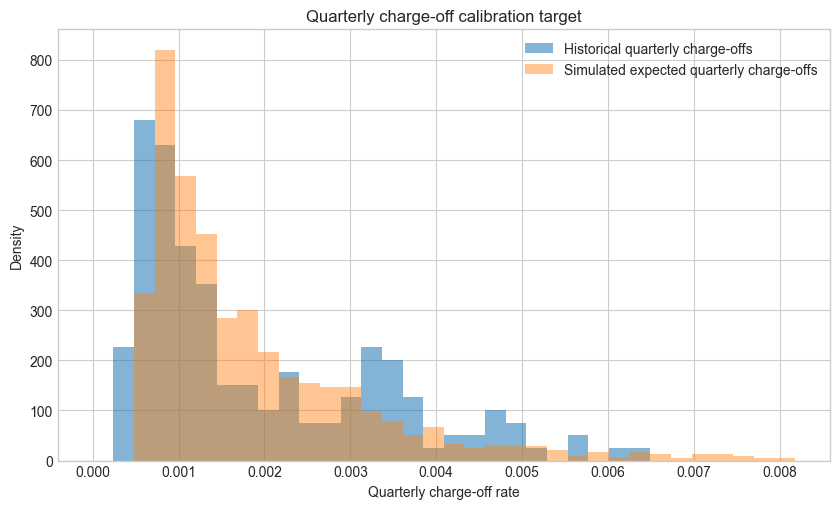

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/hist_vs_sim_expected_quarterly_chargeoffs.png


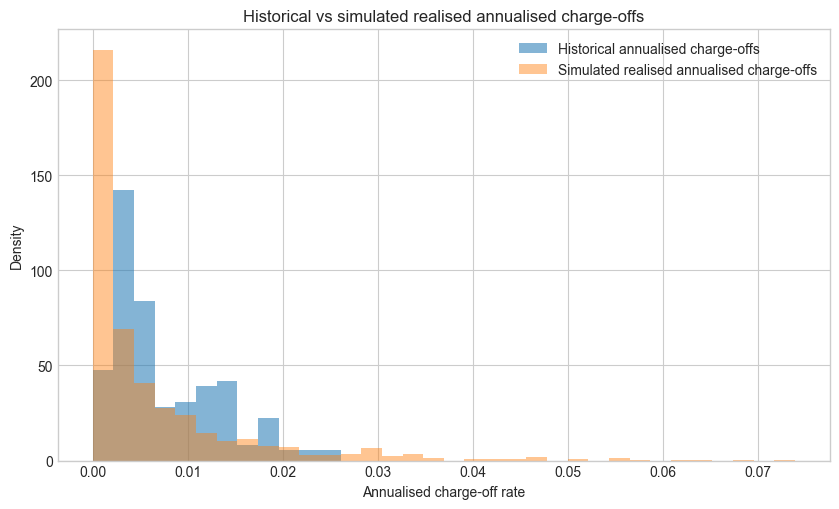

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/hist_vs_sim_annualised_chargeoffs.png


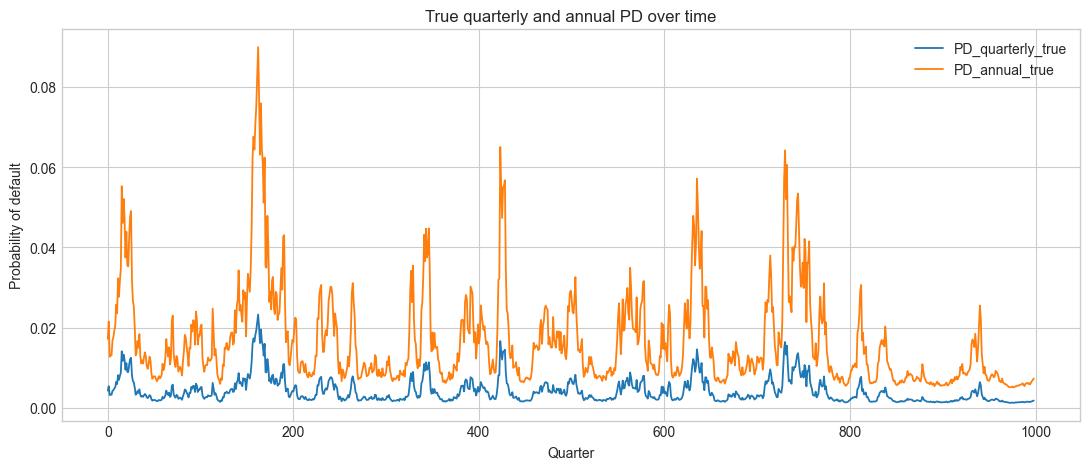

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/pd_quarterly_and_annual_over_time.png


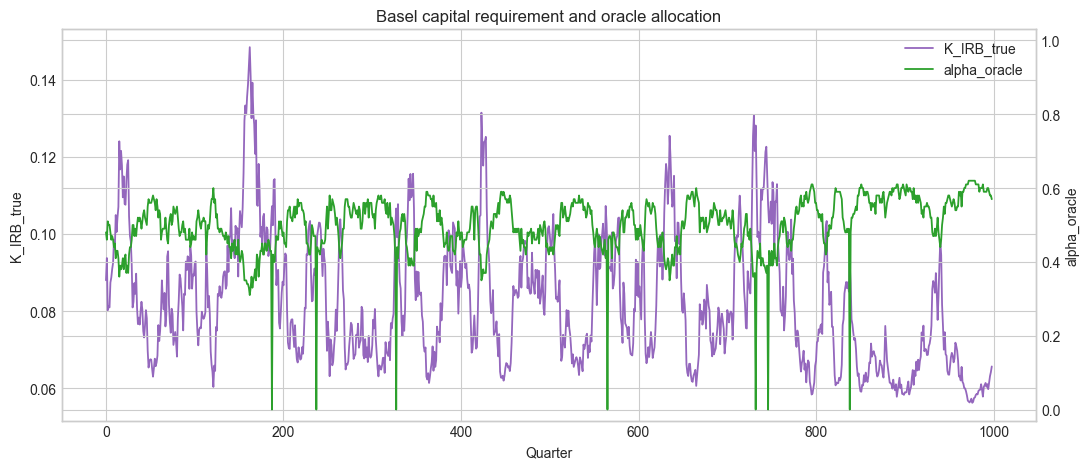

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/kirb_and_alpha_over_time.png


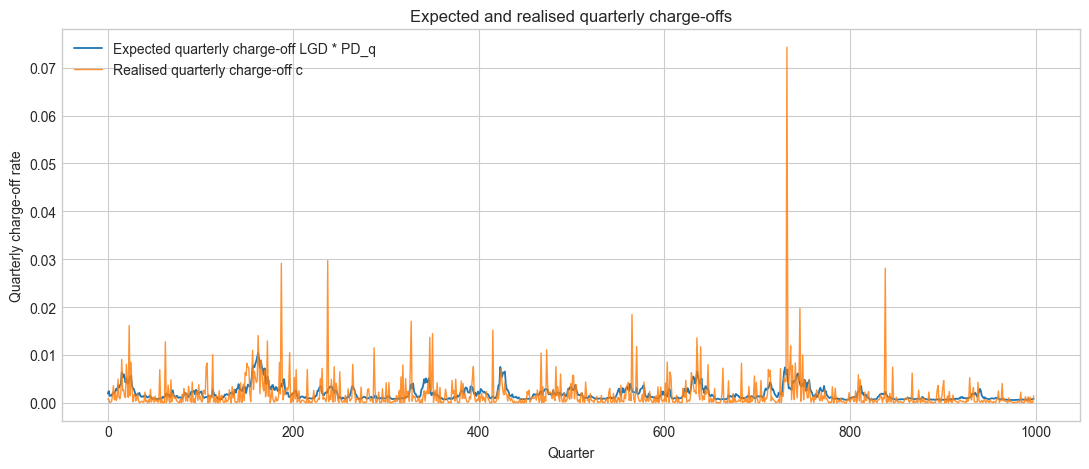

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/expected_vs_realised_quarterly_chargeoffs.png


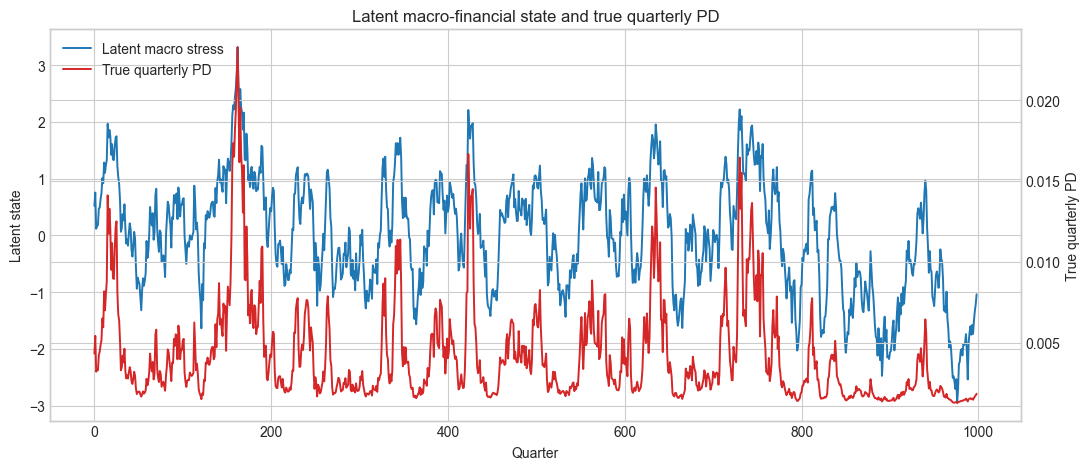

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/latent_state_and_pd.png


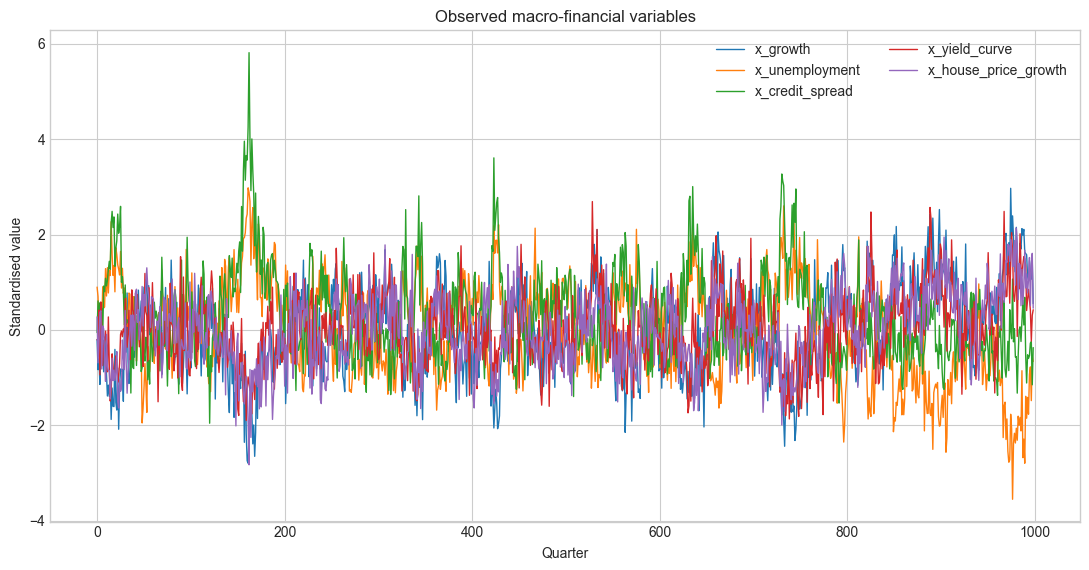

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/macro_variables.png


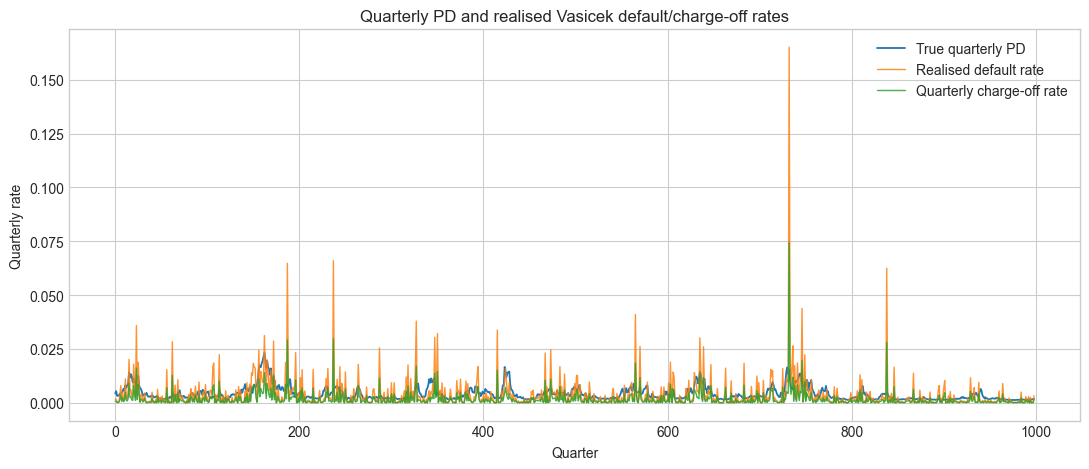

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/pd_and_chargeoffs.png


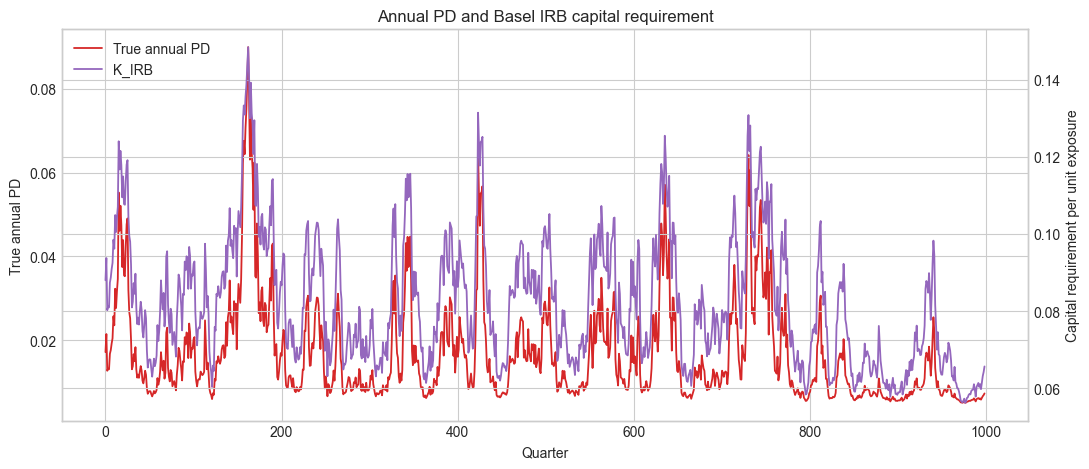

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/irb_and_pd.png


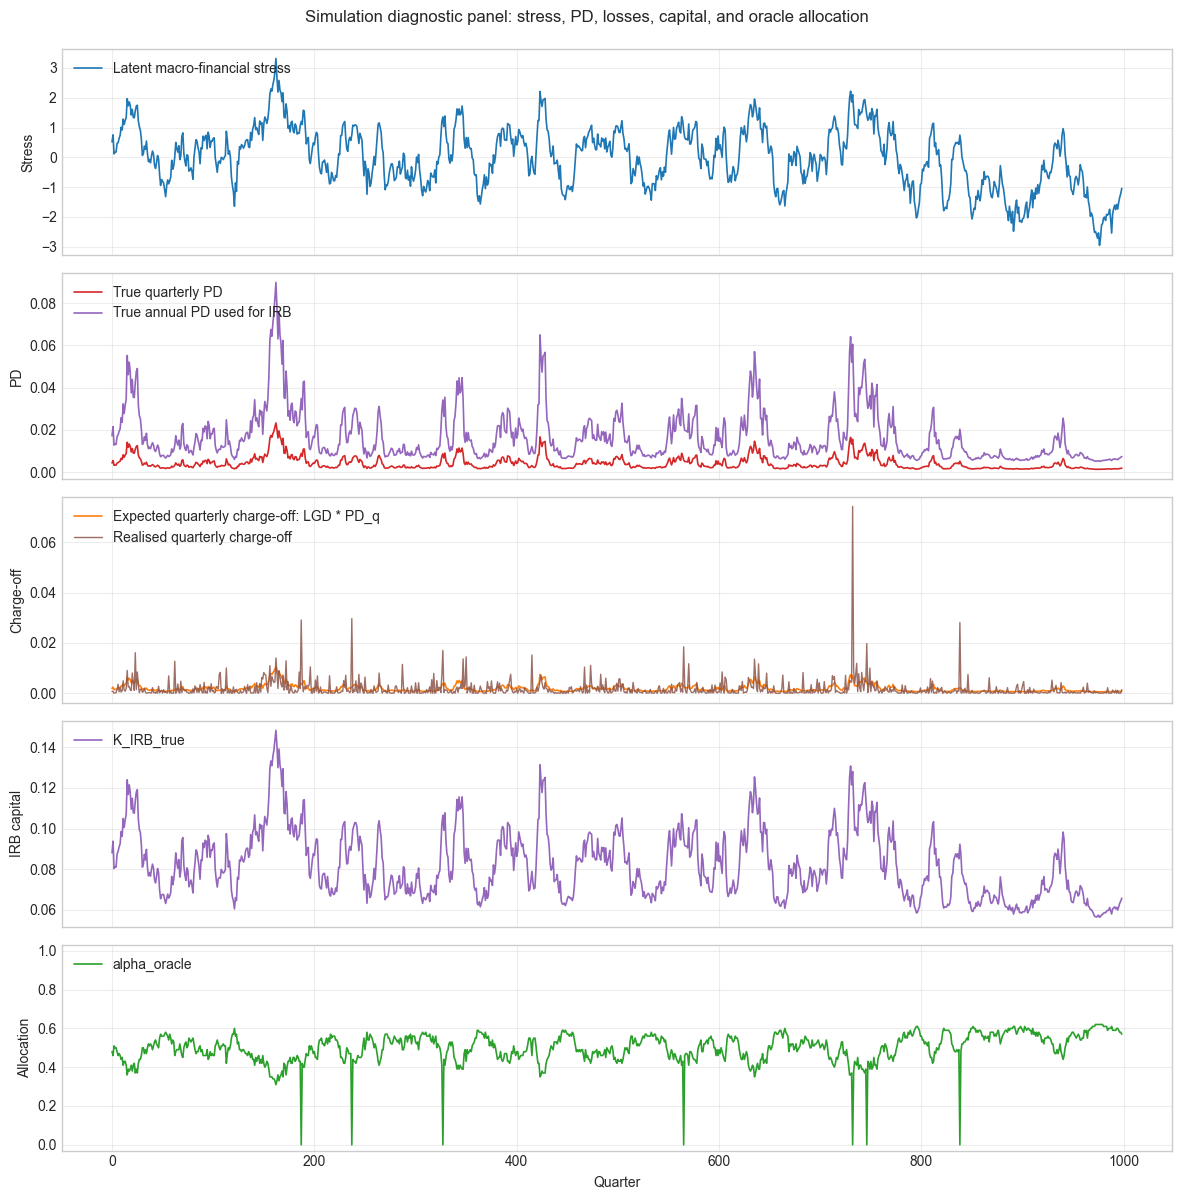

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/simulation_diagnostic_panel.png


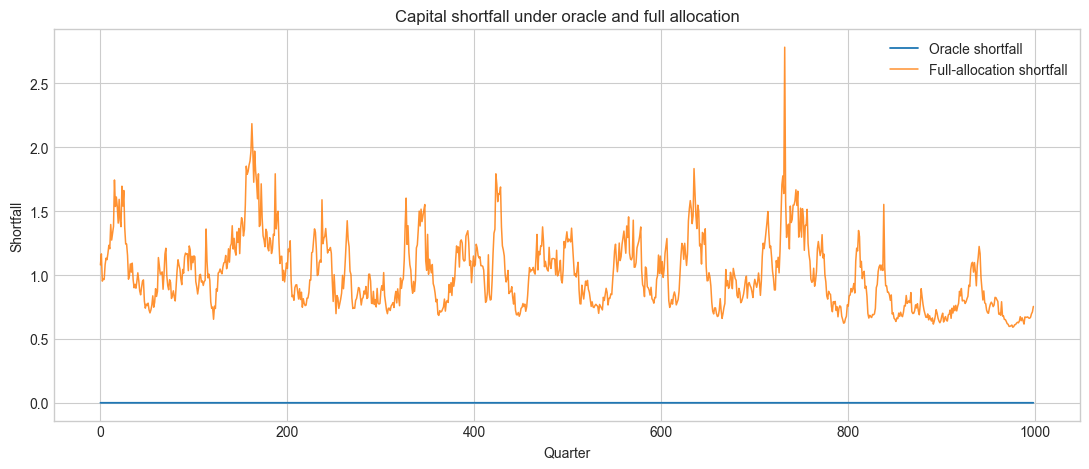

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/oracle_shortfall.png


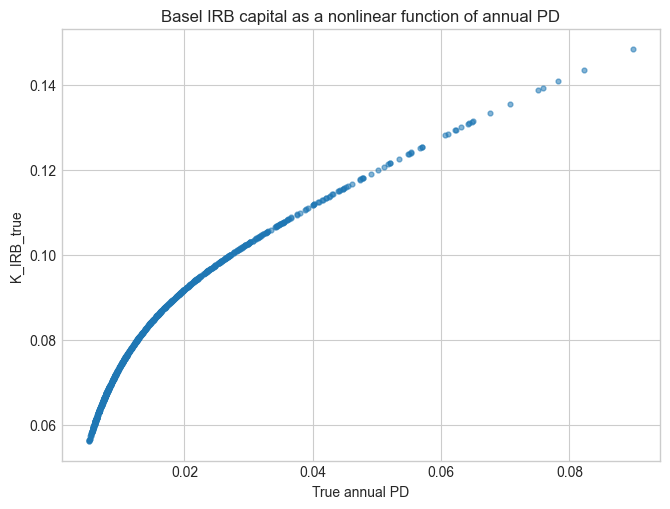

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/scatter_pd_kirb.png


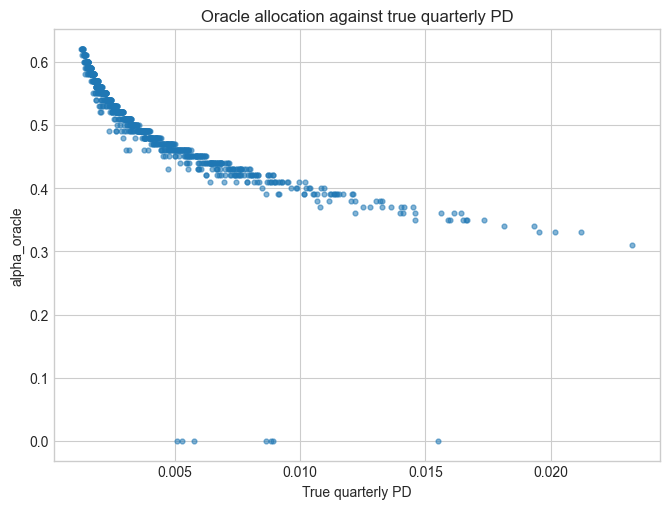

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/scatter_pd_alpha.png


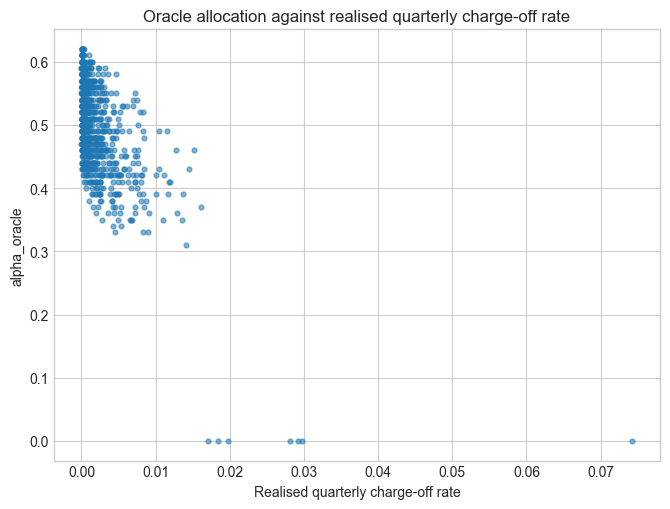

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/scatter_chargeoff_alpha.png


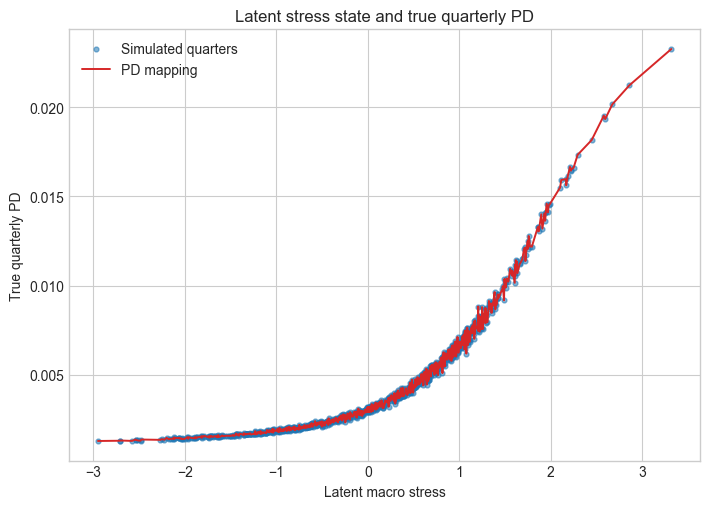

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/simulation/latent_stress_vs_pd_quarterly.png


In [252]:
plot_style = "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "seaborn-whitegrid"
plt.style.use(plot_style)


def save_current_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


x = df["t"]

# 1. Historical quarterly target vs simulated expected quarterly charge-off distribution.
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bins = np.linspace(0, max(hist_c_quarterly.quantile(0.995), df["expected_c_quarterly"].quantile(0.995)), 35)
ax.hist(hist_c_quarterly, bins=bins, density=True, alpha=0.55, label="Historical quarterly charge-offs")
ax.hist(df["expected_c_quarterly"], bins=bins, density=True, alpha=0.45, label="Simulated expected quarterly charge-offs")
ax.set_title("Quarterly charge-off calibration target")
ax.set_xlabel("Quarterly charge-off rate")
ax.set_ylabel("Density")
ax.legend()
save_current_figure("hist_vs_sim_expected_quarterly_chargeoffs.png")

# 2. Historical annualised charge-offs vs simulated realised annualised charge-offs.
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bins = np.linspace(0, max(hist_c_annualised.quantile(0.995), df["c_annualised_sim"].quantile(0.995)), 35)
ax.hist(hist_c_annualised, bins=bins, density=True, alpha=0.55, label="Historical annualised charge-offs")
ax.hist(df["c_annualised_sim"], bins=bins, density=True, alpha=0.45, label="Simulated realised annualised charge-offs")
ax.set_title("Historical vs simulated realised annualised charge-offs")
ax.set_xlabel("Annualised charge-off rate")
ax.set_ylabel("Density")
ax.legend()
save_current_figure("hist_vs_sim_annualised_chargeoffs.png")

# 3. Quarterly and annual true PD over time.
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["PD_quarterly_true"], label="PD_quarterly_true", linewidth=1.3)
ax.plot(x, df["PD_annual_true"], label="PD_annual_true", linewidth=1.3)
ax.set_title("True quarterly and annual PD over time")
ax.set_xlabel("Quarter")
ax.set_ylabel("Probability of default")
ax.legend()
save_current_figure("pd_quarterly_and_annual_over_time.png")

# 4. Basel capital and oracle allocation over time.
fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(x, df["K_IRB_true"], color="tab:purple", linewidth=1.3, label="K_IRB_true")
ax1.set_title("Basel capital requirement and oracle allocation")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("K_IRB_true")
ax2 = ax1.twinx()
ax2.plot(x, df["alpha_oracle"], color="tab:green", linewidth=1.3, label="alpha_oracle")
ax2.set_ylabel("alpha_oracle")
ax2.set_ylim(-0.03, 1.03)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper right")
save_current_figure("kirb_and_alpha_over_time.png")

# 5. Realised quarterly charge-offs versus expected quarterly charge-offs.
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["expected_c_quarterly"], label="Expected quarterly charge-off LGD * PD_q", linewidth=1.3)
ax.plot(x, df["c"], label="Realised quarterly charge-off c", linewidth=1.0, alpha=0.85)
ax.set_title("Expected and realised quarterly charge-offs")
ax.set_xlabel("Quarter")
ax.set_ylabel("Quarterly charge-off rate")
ax.legend()
save_current_figure("expected_vs_realised_quarterly_chargeoffs.png")

# Supporting thesis diagnostics retained from the original notebook.
fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(x, df["latent_state"], color="tab:blue", linewidth=1.4, label="Latent macro stress")
ax1.set_title("Latent macro-financial state and true quarterly PD")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Latent state")
ax2 = ax1.twinx()
ax2.plot(x, df["PD_quarterly_true"], color="tab:red", linewidth=1.4, label="True quarterly PD")
ax2.set_ylabel("True quarterly PD")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
save_current_figure("latent_state_and_pd.png")

fig, ax = plt.subplots(figsize=(11, 5.8))
for col in macro_cols:
    ax.plot(x, df[col], linewidth=1.0, label=col)
ax.set_title("Observed macro-financial variables")
ax.set_xlabel("Quarter")
ax.set_ylabel("Standardised value")
ax.legend(ncol=2)
save_current_figure("macro_variables.png")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["PD_quarterly_true"], label="True quarterly PD", linewidth=1.3)
ax.plot(x, df["default_rate"], label="Realised default rate", linewidth=1.0, alpha=0.85)
ax.plot(x, df["c"], label="Quarterly charge-off rate", linewidth=1.0, alpha=0.85)
ax.set_title("Quarterly PD and realised Vasicek default/charge-off rates")
ax.set_xlabel("Quarter")
ax.set_ylabel("Quarterly rate")
ax.legend()
save_current_figure("pd_and_chargeoffs.png")

fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(x, df["PD_annual_true"], color="tab:red", linewidth=1.3, label="True annual PD")
ax1.set_title("Annual PD and Basel IRB capital requirement")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("True annual PD")
ax2 = ax1.twinx()
ax2.plot(x, df["K_IRB_true"], color="tab:purple", linewidth=1.3, label="K_IRB")
ax2.set_ylabel("Capital requirement per unit exposure")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
save_current_figure("irb_and_pd.png")

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
fig.suptitle("Simulation diagnostic panel: stress, PD, losses, capital, and oracle allocation", y=0.995)

axes[0].plot(x, df["latent_state"], color="tab:blue", linewidth=1.2, label="Latent macro-financial stress")
axes[0].set_ylabel("Stress")
axes[0].legend(loc="upper left")

axes[1].plot(x, df["PD_quarterly_true"], color="tab:red", linewidth=1.2, label="True quarterly PD")
axes[1].plot(x, df["PD_annual_true"], color="tab:purple", linewidth=1.2, label="True annual PD used for IRB")
axes[1].set_ylabel("PD")
axes[1].legend(loc="upper left")

axes[2].plot(x, df["expected_c_quarterly"], color="tab:orange", linewidth=1.2, label="Expected quarterly charge-off: LGD * PD_q")
axes[2].plot(x, df["c"], color="tab:brown", linewidth=1.0, alpha=0.85, label="Realised quarterly charge-off")
axes[2].set_ylabel("Charge-off")
axes[2].legend(loc="upper left")

axes[3].plot(x, df["K_IRB_true"], color="tab:purple", linewidth=1.2, label="K_IRB_true")
axes[3].set_ylabel("IRB capital")
axes[3].legend(loc="upper left")

axes[4].plot(x, df["alpha_oracle"], color="tab:green", linewidth=1.2, label="alpha_oracle")
axes[4].set_ylabel("Allocation")
axes[4].set_xlabel("Quarter")
axes[4].set_ylim(-0.03, 1.03)
axes[4].legend(loc="upper left")

for ax in axes:
    ax.grid(True, alpha=0.35)

save_current_figure("simulation_diagnostic_panel.png")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["shortfall_oracle"], label="Oracle shortfall", linewidth=1.3)
ax.plot(x, df["shortfall_full"], label="Full-allocation shortfall", linewidth=1.1, alpha=0.85)
ax.set_title("Capital shortfall under oracle and full allocation")
ax.set_xlabel("Quarter")
ax.set_ylabel("Shortfall")
ax.legend()
save_current_figure("oracle_shortfall.png")

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(df["PD_annual_true"], df["K_IRB_true"], s=12, alpha=0.55)
ax.set_title("Basel IRB capital as a nonlinear function of annual PD")
ax.set_xlabel("True annual PD")
ax.set_ylabel("K_IRB_true")
save_current_figure("scatter_pd_kirb.png")

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(df["PD_quarterly_true"], df["alpha_oracle"], s=12, alpha=0.55)
ax.set_title("Oracle allocation against true quarterly PD")
ax.set_xlabel("True quarterly PD")
ax.set_ylabel("alpha_oracle")
save_current_figure("scatter_pd_alpha.png")

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(df["c"], df["alpha_oracle"], s=12, alpha=0.55)
ax.set_title("Oracle allocation against realised quarterly charge-off rate")
ax.set_xlabel("Realised quarterly charge-off rate")
ax.set_ylabel("alpha_oracle")
save_current_figure("scatter_chargeoff_alpha.png")

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.scatter(df["latent_state"], df["PD_quarterly_true"], s=12, alpha=0.55, label="Simulated quarters")
ordered = df.sort_values("latent_state")
ax.plot(ordered["latent_state"], ordered["PD_quarterly_true"], color="tab:red", linewidth=1.4, label="PD mapping")
ax.set_title("Latent stress state and true quarterly PD")
ax.set_xlabel("Latent macro stress")
ax.set_ylabel("True quarterly PD")
ax.legend()
save_current_figure("latent_stress_vs_pd_quarterly.png")

## Part 15 - Save output

In [112]:
preferred_order = [
    "date",
    "t",
    *macro_cols,
    "c_lag1",
    "PD_quarterly_true",
    "PD_annual_true",
    "PD_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "default_rate",
    "c",
    "c_annualised_sim",
    "R_true",
    "K_IRB_true",
    "alpha_oracle",
    "utility_oracle",
    "shortfall_oracle",
    "terminal_capital_oracle",
    "required_capital_oracle",
    "available_buffer_oracle",
    "alpha_full",
    "utility_full",
    "shortfall_full",
    "alpha_zero",
    "utility_zero",
    "latent_state",
    "latent_cycle",
]

df = df[preferred_order]
df.to_csv(CSV_PATH, index=False)

metadata = {
    "description": (
        "Synthetic quarterly PD-centric panel. The latent credit-risk process is quarterly. "
        "Annual PD is derived from quarterly PD for Basel IRB. Realised quarterly charge-offs "
        "are sampled from the Vasicek one-factor distribution using the quarterly PD threshold "
        "and Basel asset correlation based on annual PD. Oracle allocations use quarterly realised "
        "charge-offs and a linear shortfall penalty."
    ),
    "frequency_convention": {
        "historical_charge_off_rate": "Annualised quarterly FRED charge-off rate, converted to decimal if stored as percent.",
        "hist_c_quarterly": "Historical annualised charge-off divided by 4.",
        "hist_pd_quarterly": "Historical quarterly charge-off divided by LGD; main PD calibration target.",
        "hist_pd_annual": "Annual PD proxy derived from hist_pd_quarterly for IRB comparison.",
        "PD_quarterly_true": "Latent true one-quarter default probability process.",
        "PD_annual_true": "Derived one-year default probability used for Basel IRB.",
        "PD_true": "Compatibility alias for PD_quarterly_true.",
        "expected_c_quarterly": "LGD times PD_quarterly_true; main expected-loss calibration target.",
        "c": "Realised quarterly charge-off rate used in the allocation objective.",
        "c_annualised_sim": "Four times c, used only for comparison to annualised historical charge-offs.",
        "K_IRB_true": "Basel IRB capital requirement computed from PD_annual_true.",
    },
    "constants": {
        "T_raw": T,
        "T_after_lag_drop": int(len(df)),
        "LGD": LGD,
        "K1": K1,
        "ell": ell,
        "Y_BAR": Y_BAR,
        "lambda_shortfall": lambda_shortfall,
        "M": M,
        "alpha_grid_min": float(alpha_grid.min()),
        "alpha_grid_max": float(alpha_grid.max()),
        "alpha_grid_size": int(len(alpha_grid)),
        "PD_CLIP_LOW": PD_CLIP_LOW,
        "PD_CLIP_HIGH": PD_CLIP_HIGH,
        "pd_min_quarterly": pd_min,
        "pd_max_quarterly": pd_max,
        "beta0": float(beta0),
        "beta1": float(beta1),
        "beta2": beta2,
        "AUTO_CALIBRATE_PD": AUTO_CALIBRATE_PD,
        "historical_charge_off_scale_divisor": charge_off_scale,
    },
    "feature_cols": feature_cols,
    "diagnostic_cols": diagnostic_cols,
    "random_seed": SEED,
    "quarterly_expected_chargeoff_table": quarterly_expected_chargeoff_table.to_dict(),
    "annual_pd_table": annual_pd_table.to_dict(),
    "realised_annualised_chargeoff_table": realised_annualised_chargeoff_table.to_dict(),
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved panel to: {CSV_PATH}")
print(f"Saved metadata to: {METADATA_PATH}")

Saved panel to: /Users/hannahokeeffe/Documents/Imperial/DFL_New/data/simulated_pd_panel.csv
Saved metadata to: /Users/hannahokeeffe/Documents/Imperial/DFL_New/data/simulated_pd_panel_metadata.json


## Part 16 - Notebook ending

In [ ]:
print(f"Saved CSV path: {CSV_PATH}")
print(f"Number of observations: {len(df)}")
print("\nFeature columns allowed as model inputs:")
print(feature_cols)
print("\nDiagnostic-only columns, not model inputs:")
print(diagnostic_cols)
print("\nReminder: PTO and BB notebooks should read this panel and use only feature_cols as inputs.")
print("Later models should predict quarterly PD for the quarterly decision problem, then annualise for Basel IRB where needed.")

In [199]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[feature_cols].to_numpy()
y = df["PD_true"].to_numpy()

tscv = TimeSeriesSplit(n_splits=5)
r2_scores = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    model = LinearRegression().fit(X[train_idx], y[train_idx])
    r2 = model.score(X[test_idx], y[test_idx])
    r2_scores.append(r2)
    print(f"Fold {fold}: train={len(train_idx)}, test={len(test_idx)}, R²={r2:.4f}")

print(f"\nMean R² across folds: {np.mean(r2_scores):.4f}")
print(f"Std R² across folds:  {np.std(r2_scores):.4f}")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold}: train mean={y[train_idx].mean():.4f}, test mean={y[test_idx].mean():.4f}")

Fold 0: train=169, test=166, R²=0.6900
Fold 1: train=335, test=166, R²=0.8079
Fold 2: train=501, test=166, R²=0.7886
Fold 3: train=667, test=166, R²=0.8433
Fold 4: train=833, test=166, R²=-1.0233

Mean R² across folds: 0.4213
Std R² across folds:  0.7241
Fold 0: train mean=0.0056, test mean=0.0041
Fold 1: train mean=0.0049, test mean=0.0046
Fold 2: train mean=0.0048, test mean=0.0043
Fold 3: train mean=0.0046, test mean=0.0046
Fold 4: train mean=0.0046, test mean=0.0021


In [198]:
from sklearn.ensemble import GradientBoostingRegressor
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    m = GradientBoostingRegressor(max_depth=3, n_estimators=200).fit(X[train_idx], y[train_idx])
    print(f"Fold {fold} GBR R²: {m.score(X[test_idx], y[test_idx]):.4f}")

Fold 0 GBR R²: 0.8662
Fold 1 GBR R²: 0.8763
Fold 2 GBR R²: 0.8772
Fold 3 GBR R²: 0.8797
Fold 4 GBR R²: 0.7888
